# Colab 2 — Motivating empirical evidence for the proposed methodology

This notebook develops the empirical diagnostics that motivate the methodological choices of the article.

## Objectives
1. Examine whether age, brand/model, and hospital context carry observable signal related to future operational burden.
2. Assess whether the age profile is monotonic or suggests survivorship, decommissioning, or reduced exposure effects.
3. Quantify preliminary heterogeneity across brands and hospitals.
4. Produce figures and summary tables that can later support the motivating section of the manuscript.

## Position within the article
This notebook does **not** aim to provide the final inferential evidence of the study.  
Instead, it provides preliminary empirical structure showing why a latent, hierarchical, and decision-oriented methodology may be necessary.

In [1]:
# ============================================
# 1) Imports and configuration
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = "analytic_cohort_for_modeling.csv"

In [2]:
# ============================================
# 2) Load analytical cohort
# ============================================
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Shape: (14809, 41)


,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,model_hash,LEITOS_EXISTENTES_z,LEITOS_SUS_z,UTI_TOTAL_EXIST_z,UTI_TOTAL_SUS_z,UTI_ADULTO_EXIST_z,UTI_ADULTO_SUS_z,UTI_PEDIATRICO_EXIST_z,UTI_PEDIATRICO_SUS_z,UTI_NEONATAL_EXIST_z,UTI_NEONATAL_SUS_z,log_cm_count,log_total_downtime,log_max_downtime,downtime_per_cm,log_downtime_per_cm,downtime_event_intensity,log_downtime_event_intensity,age_band,cm_count_lag1,total_downtime_lag1,any_downtime_lag1,age_lag1,cm_count_expanding_mean_lag1,downtime_expanding_mean_lag1,delta_cm_vs_lag1,delta_downtime_vs_lag1,cm_count_t_plus_1,downtime_t_plus_1,any_downtime_t_plus_1,high_downtime_t_plus_1
0,eq_00339a54eaa6,h_f3391264376f,2022,2.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.163034,1.173656,1.139074,0.934462,0.501098,0.560743,1.321094,1.321094,1.064779,1.121053,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,eq_00339a54eaa6,h_f3391264376f,2023,3.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.189540,1.214732,1.015032,0.933842,-0.184465,-0.090361,1.275125,1.305313,1.105163,1.141548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,186.0,1.0,1.0
2,eq_00339a54eaa6,h_f3391264376f,2024,4.0,1.0,186.0,1.0,186.0,1,b_b5582bab280c,m_0f2cb0e1a162,1.086737,1.125939,0.810040,0.865332,-0.289683,-0.150083,0.934306,1.132643,1.069034,1.079456,0.693147,5.231109,5.231109,185.999814,5.231108,185.999814,5.231108,<=5,0.0,0.0,0.0,3.0,0.0,0.0,1.0,186.0,1.0,27.0,1.0,0.0
3,eq_0044d3ea0082,h_b052b2239a62,2023,0.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.467852,-0.376477,-1.022215,-0.729593,-0.184465,-0.090361,-0.893161,-0.890962,-1.504843,-1.480203,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,eq_0044d3ea0082,h_b052b2239a62,2024,1.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.527059,-0.450616,-1.230858,-0.886312,-0.289683,-0.150083,-1.210405,-1.014119,-1.539650,-1.534416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,0.0


equip_hash                       object
hospital_hash                    object
year                              int64
age_at_year                     float64
cm_count                        float64
total_downtime_hours            float64
positive_downtime_count         float64
max_downtime                    float64
any_downtime                      int64
brand_hash                       object
model_hash                       object
LEITOS_EXISTENTES_z             float64
LEITOS_SUS_z                    float64
UTI_TOTAL_EXIST_z               float64
UTI_TOTAL_SUS_z                 float64
UTI_ADULTO_EXIST_z              float64
UTI_ADULTO_SUS_z                float64
UTI_PEDIATRICO_EXIST_z          float64
UTI_PEDIATRICO_SUS_z            float64
UTI_NEONATAL_EXIST_z            float64
UTI_NEONATAL_SUS_z              float64
log_cm_count                    float64
log_total_downtime              float64
log_max_downtime                float64
downtime_per_cm                 float64


## Required columns
This notebook assumes the existence of the analytical cohort exported by Colab 1, including the following variables:

- `equip_hash`
- `hospital_hash`
- `brand_hash`
- `model_hash`
- `year`
- `age_at_year`
- `age_band`
- `cm_count`
- `total_downtime_hours`
- `any_downtime`
- `cm_count_t_plus_1`
- `downtime_t_plus_1`
- `high_downtime_t_plus_1`

In [3]:
# ============================================
# 3) Basic checks
# ============================================
required_cols = [
    "equip_hash", "hospital_hash", "brand_hash", "model_hash", "year",
    "age_at_year", "age_band", "cm_count", "total_downtime_hours",
    "any_downtime", "cm_count_t_plus_1", "downtime_t_plus_1",
    "high_downtime_t_plus_1"
]

missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f"Missing columns: {missing_required}"

print("Number of hospitals:", df["hospital_hash"].nunique())
print("Number of equipment units:", df["equip_hash"].nunique())
print("Number of brands:", df["brand_hash"].nunique())
print("Number of models:", df["model_hash"].nunique())

Number of hospitals: 39
Number of equipment units: 5503
Number of brands: 35
Number of models: 141


# 4. Age-profile diagnostics

The first question is whether chronological age alone provides a sufficiently clear representation of future operational risk.  
If the relationship is non-monotonic, this would already suggest that age is at best an incomplete proxy of deterioration.

In [4]:
# ============================================
# 4.1) Age-band summary
# ============================================
age_summary = df.groupby("age_band", observed=False).agg(
    n=("equip_hash", "size"),
    unique_equipment=("equip_hash", "nunique"),
    mean_age=("age_at_year", "mean"),
    mean_cm=("cm_count", "mean"),
    mean_downtime=("total_downtime_hours", "mean"),
    median_downtime=("total_downtime_hours", "median"),
    zero_cm_rate=("cm_count", lambda s: np.mean(s == 0)),
    zero_downtime_rate=("total_downtime_hours", lambda s: np.mean(s == 0)),
    future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
).reset_index()

display(age_summary)

,age_band,n,unique_equipment,mean_age,mean_cm,mean_downtime,median_downtime,zero_cm_rate,zero_downtime_rate,future_high_downtime_rate
0,11-15,2034,889,12.515733,1.240905,293.446411,0.0,0.485742,0.504916,0.302852
1,16-20,358,176,17.946927,1.569832,215.639665,5.0,0.410615,0.449721,0.282123
2,6-10,3749,1955,7.523340,0.951454,368.919178,0.0,0.553481,0.572153,0.264604
3,<=5,8408,3866,2.668887,0.688273,265.637607,0.0,0.647122,0.663535,0.232160
4,>20,260,109,22.603846,0.588462,277.965385,0.0,0.665385,0.676923,0.184615


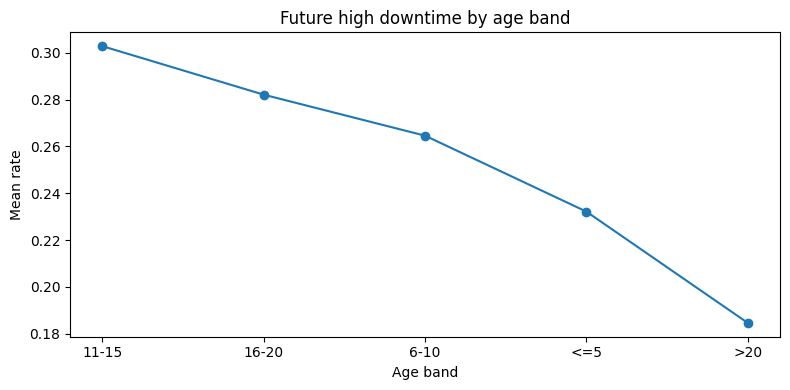

In [5]:
# ============================================
# 4.2) Future high downtime by age band
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(age_summary["age_band"].astype(str), age_summary["future_high_downtime_rate"], marker="o")
plt.title("Future high downtime by age band")
plt.xlabel("Age band")
plt.ylabel("Mean rate")
plt.tight_layout()
plt.show()

,age_band,mean_downtime,std_downtime,p75_downtime,p90_downtime
0,11-15,293.446411,1170.103696,91.0,442.4
1,16-20,215.639665,1152.575283,78.5,326.3
2,6-10,368.919178,1492.714681,69.0,454.4
3,<=5,265.637607,1382.068915,25.0,285.0
4,>20,277.965385,1156.015415,17.5,281.4


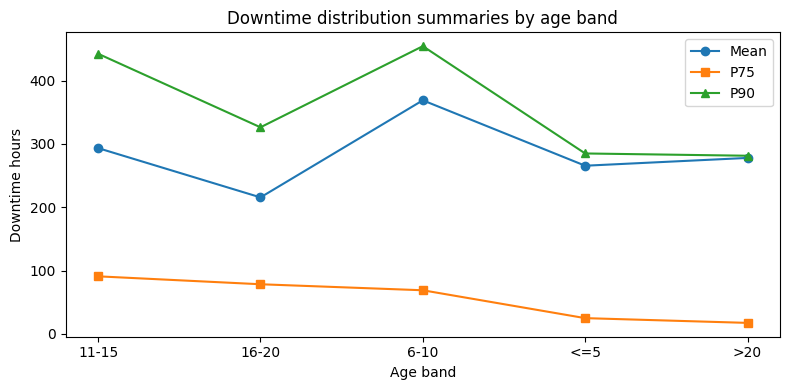

In [6]:
# ============================================
# 4.3) Mean and dispersion of downtime by age band
# ============================================
age_dispersion = df.groupby("age_band", observed=False).agg(
    mean_downtime=("total_downtime_hours", "mean"),
    std_downtime=("total_downtime_hours", "std"),
    p75_downtime=("total_downtime_hours", lambda s: np.quantile(s, 0.75)),
    p90_downtime=("total_downtime_hours", lambda s: np.quantile(s, 0.90))
).reset_index()

display(age_dispersion)

plt.figure(figsize=(8, 4))
plt.plot(age_dispersion["age_band"].astype(str), age_dispersion["mean_downtime"], marker="o", label="Mean")
plt.plot(age_dispersion["age_band"].astype(str), age_dispersion["p75_downtime"], marker="s", label="P75")
plt.plot(age_dispersion["age_band"].astype(str), age_dispersion["p90_downtime"], marker="^", label="P90")
plt.title("Downtime distribution summaries by age band")
plt.xlabel("Age band")
plt.ylabel("Downtime hours")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation note
A non-monotonic age pattern may reflect several mechanisms beyond biological or mechanical aging alone:
- survivorship selection;
- decommissioning of highly problematic older units;
- lower exposure or reserve use among very old equipment;
- compositional differences in brands, models, or hospitals.

The following sections explore these possibilities descriptively.

# 5. Survivorship and reduced-exposure diagnostics

Because the analytical cohort only contains observations with a defined future outcome, the next step is to examine whether very old units also exhibit signals compatible with lower exposure or selective persistence.

,age_band,zero_cm_rate,zero_downtime_rate,zero_any_downtime_rate
0,11-15,0.485742,0.504916,0.504916
1,16-20,0.410615,0.449721,0.449721
2,6-10,0.553481,0.572153,0.572153
3,<=5,0.647122,0.663535,0.663535
4,>20,0.665385,0.676923,0.676923


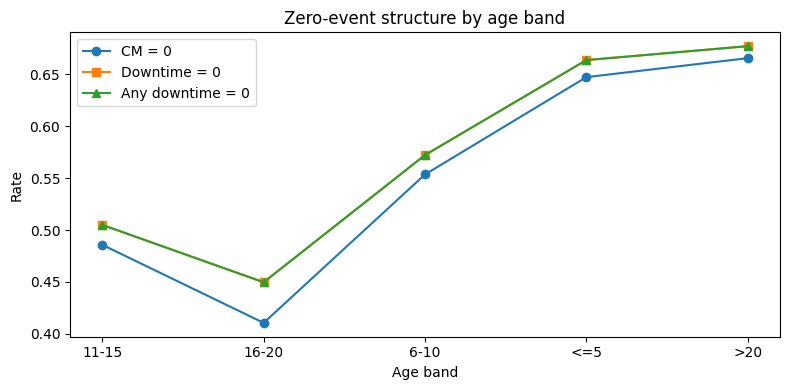

In [7]:
# ============================================
# 5.1) Zero-event structure by age band
# ============================================
zero_structure = df.groupby("age_band", observed=False).agg(
    zero_cm_rate=("cm_count", lambda s: np.mean(s == 0)),
    zero_downtime_rate=("total_downtime_hours", lambda s: np.mean(s == 0)),
    zero_any_downtime_rate=("any_downtime", lambda s: np.mean(s == 0))
).reset_index()

display(zero_structure)

plt.figure(figsize=(8, 4))
plt.plot(zero_structure["age_band"].astype(str), zero_structure["zero_cm_rate"], marker="o", label="CM = 0")
plt.plot(zero_structure["age_band"].astype(str), zero_structure["zero_downtime_rate"], marker="s", label="Downtime = 0")
plt.plot(zero_structure["age_band"].astype(str), zero_structure["zero_any_downtime_rate"], marker="^", label="Any downtime = 0")
plt.title("Zero-event structure by age band")
plt.xlabel("Age band")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()

,age_band,n_rows,n_equipment
0,11-15,2034,889
1,16-20,358,176
2,6-10,3749,1955
3,<=5,8408,3866
4,>20,260,109


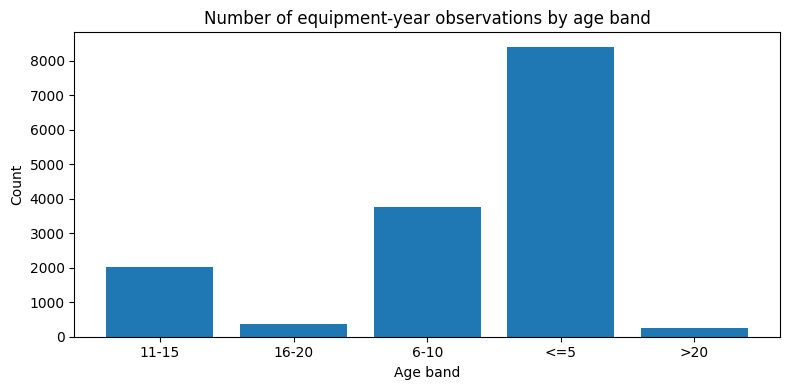

In [8]:
# ============================================
# 5.2) Number of observations and unique equipment by age band
# ============================================
age_count = df.groupby("age_band", observed=False).agg(
    n_rows=("equip_hash", "size"),
    n_equipment=("equip_hash", "nunique")
).reset_index()

display(age_count)

plt.figure(figsize=(8, 4))
plt.bar(age_count["age_band"].astype(str), age_count["n_rows"])
plt.title("Number of equipment-year observations by age band")
plt.xlabel("Age band")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 6. Brand-level heterogeneity

If brands exhibit systematically different operational profiles, then chronological age alone cannot fully represent deterioration.  
However, rankings based on small sample sizes may be unstable, so minimum-volume filters should be considered.

In [9]:
# ============================================
# 6.1) Brand summary (full)
# ============================================
brand_summary = (
    df.groupby("brand_hash")
    .agg(
        n=("equip_hash", "size"),
        unique_equipment=("equip_hash", "nunique"),
        mean_age=("age_at_year", "mean"),
        mean_cm=("cm_count", "mean"),
        mean_downtime=("total_downtime_hours", "mean"),
        future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
    )
    .sort_values("future_high_downtime_rate", ascending=False)
)

display(brand_summary.head(15))

,n,unique_equipment,mean_age,mean_cm,mean_downtime,future_high_downtime_rate
brand_hash,,,,,,
b_e2e2917b1e32,1,1,0.000000,2.000000,1.000000,1.000000
b_0f1d0f827474,18,6,2.000000,3.277778,1157.888889,0.722222
b_6b3725d0d45d,43,21,2.162791,1.790698,447.069767,0.534884
b_9a6bf9295f3d,195,65,4.584615,1.441026,450.856410,0.374359
b_865015c653a8,105,35,9.657143,0.847619,122.342857,0.323810
b_da80075e3434,240,80,5.950000,1.404167,119.354167,0.308333
b_af56f90db2f0,39,13,14.076923,0.794872,140.384615,0.307692
b_ed9adb9799e9,33,11,6.818182,0.727273,566.242424,0.303030
b_31a19c993a76,54,20,2.555556,1.185185,89.388889,0.296296


,n,unique_equipment,mean_age,mean_cm,mean_downtime,future_high_downtime_rate
brand_hash,,,,,,
b_6b3725d0d45d,43,21,2.162791,1.790698,447.069767,0.534884
b_9a6bf9295f3d,195,65,4.584615,1.441026,450.856410,0.374359
b_865015c653a8,105,35,9.657143,0.847619,122.342857,0.323810
b_da80075e3434,240,80,5.950000,1.404167,119.354167,0.308333
b_af56f90db2f0,39,13,14.076923,0.794872,140.384615,0.307692
b_ed9adb9799e9,33,11,6.818182,0.727273,566.242424,0.303030
b_31a19c993a76,54,20,2.555556,1.185185,89.388889,0.296296
b_a47838d14cfe,798,266,10.571429,1.018797,201.156642,0.295739
b_be7b7d3371ed,2435,813,10.851335,1.157290,297.858316,0.294867


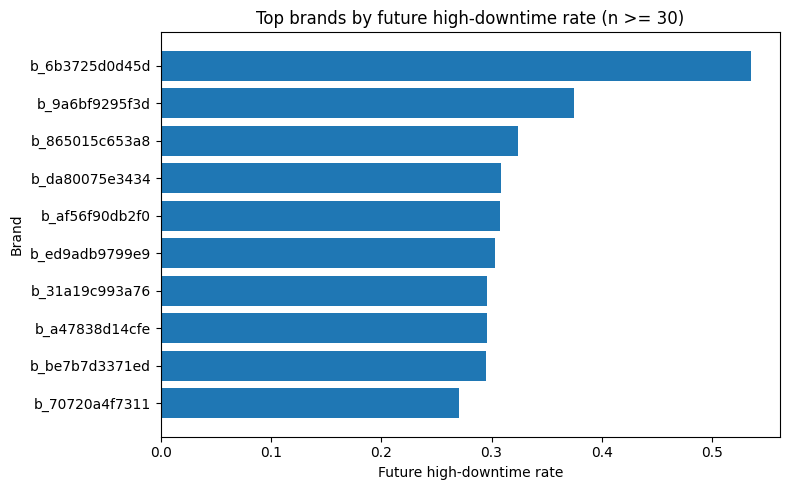

In [10]:
# ============================================
# 6.2) Brand summary with minimum sample-size filter
# ============================================
MIN_BRAND_N = 30

brand_summary_filtered = brand_summary[brand_summary["n"] >= MIN_BRAND_N].copy()
display(brand_summary_filtered.head(15))

plt.figure(figsize=(8, 5))
top_brands = brand_summary_filtered.head(10).sort_values("future_high_downtime_rate")
plt.barh(top_brands.index.astype(str), top_brands["future_high_downtime_rate"])
plt.title(f"Top brands by future high-downtime rate (n >= {MIN_BRAND_N})")
plt.xlabel("Future high-downtime rate")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

In [11]:
# ============================================
# 6.3) Age-adjusted brand descriptives
# ============================================
brand_age_band = (
    df.groupby(["brand_hash", "age_band"], observed=False)
    .agg(
        n=("equip_hash", "size"),
        mean_downtime=("total_downtime_hours", "mean"),
        future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
    )
    .reset_index()
)

display(brand_age_band.head(20))

,brand_hash,age_band,n,mean_downtime,future_high_downtime_rate
0,b_007ee028fdef,11-15,192,538.572917,0.187500
1,b_007ee028fdef,16-20,4,4.750000,0.250000
2,b_007ee028fdef,6-10,511,611.199609,0.293542
3,b_007ee028fdef,<=5,282,220.914894,0.262411
4,b_007ee028fdef,>20,48,675.416667,0.208333
5,b_0f1d0f827474,<=5,18,1157.888889,0.722222
6,b_150edee60925,6-10,326,289.604294,0.150307
7,b_150edee60925,<=5,356,144.921348,0.247191
8,b_150edee60925,>20,21,270.000000,0.095238
9,b_25045cf18197,<=5,6,7.500000,0.000000


# 7. Hospital-level heterogeneity

Hospital-level variation may reflect contextual differences in use intensity, maintenance governance, case mix, and organizational processes.  
This is one of the key empirical motivations for a hierarchical formulation.

In [12]:
# ============================================
# 7.1) Hospital summary (full)
# ============================================
hospital_summary = (
    df.groupby("hospital_hash")
    .agg(
        n=("equip_hash", "size"),
        unique_equipment=("equip_hash", "nunique"),
        mean_age=("age_at_year", "mean"),
        mean_cm=("cm_count", "mean"),
        mean_downtime=("total_downtime_hours", "mean"),
        future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
    )
    .sort_values("future_high_downtime_rate", ascending=False)
)

display(hospital_summary.head(15))

,n,unique_equipment,mean_age,mean_cm,mean_downtime,future_high_downtime_rate
hospital_hash,,,,,,
h_98004e5f5a8f,377,127,5.244032,1.477454,1186.978780,0.615385
h_9a2bfa5dd4b6,126,45,6.357143,2.253968,135.634921,0.515873
h_d90e01eb9931,629,248,3.841017,1.187599,359.796502,0.494436
h_2cc501c53d90,246,96,3.926829,1.126016,325.223577,0.422764
h_87a15588f3d1,292,108,6.883562,1.513699,461.732877,0.414384
h_e41ff37e36a1,228,77,6.013158,1.078947,537.434211,0.412281
h_4268c4662dae,249,83,7.831325,3.020080,367.389558,0.409639
h_a361c6f93235,51,17,6.117647,0.313725,1862.176471,0.392157
h_12dcdfb79130,492,169,6.024390,1.758130,400.678862,0.382114


,n,unique_equipment,mean_age,mean_cm,mean_downtime,future_high_downtime_rate
hospital_hash,,,,,,
h_98004e5f5a8f,377,127,5.244032,1.477454,1186.978780,0.615385
h_9a2bfa5dd4b6,126,45,6.357143,2.253968,135.634921,0.515873
h_d90e01eb9931,629,248,3.841017,1.187599,359.796502,0.494436
h_2cc501c53d90,246,96,3.926829,1.126016,325.223577,0.422764
h_87a15588f3d1,292,108,6.883562,1.513699,461.732877,0.414384
h_e41ff37e36a1,228,77,6.013158,1.078947,537.434211,0.412281
h_4268c4662dae,249,83,7.831325,3.020080,367.389558,0.409639
h_a361c6f93235,51,17,6.117647,0.313725,1862.176471,0.392157
h_12dcdfb79130,492,169,6.024390,1.758130,400.678862,0.382114


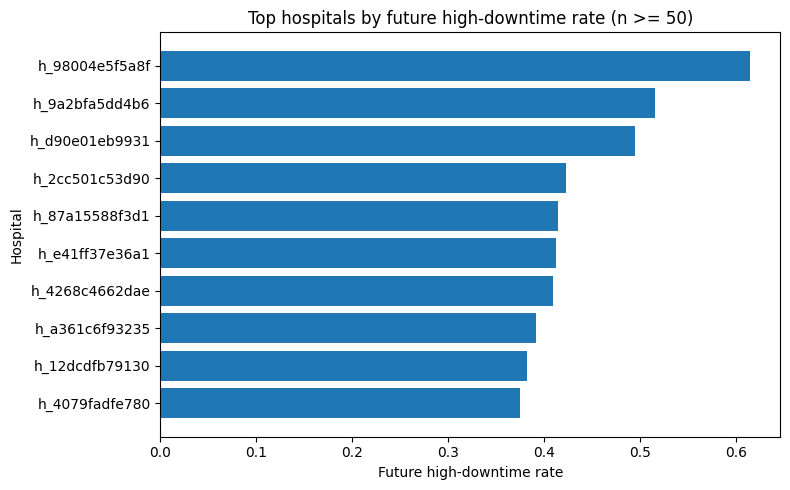

In [13]:
# ============================================
# 7.2) Hospital summary with minimum sample-size filter
# ============================================
MIN_HOSPITAL_N = 50

hospital_summary_filtered = hospital_summary[hospital_summary["n"] >= MIN_HOSPITAL_N].copy()
display(hospital_summary_filtered.head(15))

plt.figure(figsize=(8, 5))
top_hospitals = hospital_summary_filtered.head(10).sort_values("future_high_downtime_rate")
plt.barh(top_hospitals.index.astype(str), top_hospitals["future_high_downtime_rate"])
plt.title(f"Top hospitals by future high-downtime rate (n >= {MIN_HOSPITAL_N})")
plt.xlabel("Future high-downtime rate")
plt.ylabel("Hospital")
plt.tight_layout()
plt.show()

,hospital_hash,age_band,n,future_high_downtime_rate
0,h_2cc501c53d90,11-15,9,0.555556
1,h_2cc501c53d90,6-10,52,0.576923
2,h_2cc501c53d90,<=5,185,0.372973
3,h_87a15588f3d1,11-15,85,0.388235
4,h_87a15588f3d1,6-10,86,0.418605
5,h_87a15588f3d1,<=5,121,0.429752
6,h_98004e5f5a8f,11-15,31,0.483871
7,h_98004e5f5a8f,6-10,75,0.640000
8,h_98004e5f5a8f,<=5,271,0.623616
9,h_d90e01eb9931,11-15,57,0.315789


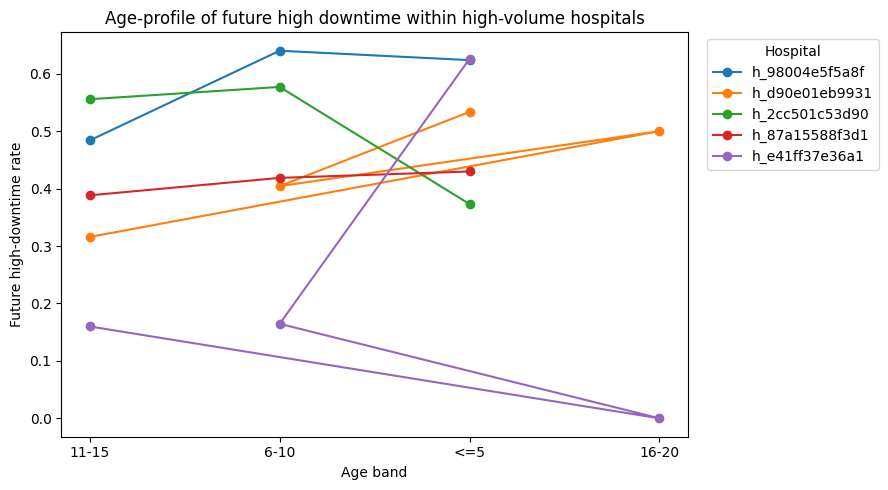

In [14]:
# ============================================
# 7.3) Within-hospital age profiles for high-volume hospitals
# ============================================
high_volume_hospitals = hospital_summary[hospital_summary["n"] >= 200].head(5).index.tolist()

subset = df[df["hospital_hash"].isin(high_volume_hospitals)].copy()

hospital_age_profile = (
    subset.groupby(["hospital_hash", "age_band"], observed=False)
    .agg(
        n=("equip_hash", "size"),
        future_high_downtime_rate=("high_downtime_t_plus_1", "mean")
    )
    .reset_index()
)

display(hospital_age_profile.head(20))

plt.figure(figsize=(9, 5))
for hosp in high_volume_hospitals:
    tmp = hospital_age_profile[hospital_age_profile["hospital_hash"] == hosp]
    plt.plot(tmp["age_band"].astype(str), tmp["future_high_downtime_rate"], marker="o", label=str(hosp))

plt.title("Age-profile of future high downtime within high-volume hospitals")
plt.xlabel("Age band")
plt.ylabel("Future high-downtime rate")
plt.legend(title="Hospital", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 8. Brand-hospital composition diagnostics

High observed rates may reflect compositional concentration rather than an isolated effect of brand or hospital.  
The purpose of this section is not to identify causal effects, but to show that composition matters and that simple marginal comparisons may be misleading.

In [15]:
# ============================================
# 8.1) Top brands by hospital concentration
# ============================================
brand_hospital_counts = (
    df.groupby(["brand_hash", "hospital_hash"])
    .size()
    .reset_index(name="n")
)

brand_concentration = (
    brand_hospital_counts.sort_values(["brand_hash", "n"], ascending=[True, False])
    .groupby("brand_hash")
    .head(1)
    .rename(columns={"hospital_hash": "top_hospital_for_brand", "n": "top_hospital_count"})
)

brand_total = df.groupby("brand_hash").size().reset_index(name="brand_total_n")
brand_concentration = brand_concentration.merge(brand_total, on="brand_hash", how="left")
brand_concentration["top_hospital_share"] = brand_concentration["top_hospital_count"] / brand_concentration["brand_total_n"]

display(brand_concentration.sort_values("top_hospital_share", ascending=False).head(15))

,brand_hash,top_hospital_for_brand,top_hospital_count,brand_total_n,top_hospital_share
8,b_39d8c17e519b,h_0cb185a47dc6,3,3,1.000000
5,b_2b13ece468ac,h_b052b2239a62,3,3,1.000000
3,b_25045cf18197,h_09b0ca23e327,6,6,1.000000
30,b_e2e2917b1e32,h_e176ae8ff561,1,1,1.000000
34,b_fa44fa73be91,h_98004e5f5a8f,1,1,1.000000
18,b_879873edabf9,h_d90e01eb9931,26,26,1.000000
7,b_37290bcd892f,h_1222eff4401f,6,6,1.000000
9,b_3de38cb095b1,h_8e1d304da24c,3,3,1.000000
10,b_492b237c6945,h_152fefdf3496,21,21,1.000000
25,b_c43d20176d18,h_8e1d304da24c,3,3,1.000000


In [16]:
# ============================================
# 8.2) Top hospitals by brand concentration
# ============================================
hospital_brand_counts = (
    df.groupby(["hospital_hash", "brand_hash"])
    .size()
    .reset_index(name="n")
)

hospital_concentration = (
    hospital_brand_counts.sort_values(["hospital_hash", "n"], ascending=[True, False])
    .groupby("hospital_hash")
    .head(1)
    .rename(columns={"brand_hash": "top_brand_for_hospital", "n": "top_brand_count"})
)

hospital_total = df.groupby("hospital_hash").size().reset_index(name="hospital_total_n")
hospital_concentration = hospital_concentration.merge(hospital_total, on="hospital_hash", how="left")
hospital_concentration["top_brand_share"] = hospital_concentration["top_brand_count"] / hospital_concentration["hospital_total_n"]

display(hospital_concentration.sort_values("top_brand_share", ascending=False).head(15))

,hospital_hash,top_brand_for_hospital,top_brand_count,hospital_total_n,top_brand_share
22,h_a361c6f93235,b_55093b182955,48,51,0.941176
30,h_d9120af40e7f,b_293446a1fb5f,333,357,0.932773
13,h_53006a5b1c48,b_b5582bab280c,114,137,0.832117
24,h_b4c7314b4322,b_293446a1fb5f,207,266,0.778195
31,h_d9bb165ee9e3,b_be7b7d3371ed,6,9,0.666667
6,h_26acf655f9bc,b_b5582bab280c,259,416,0.622596
2,h_1222eff4401f,b_be7b7d3371ed,123,219,0.561644
3,h_12dcdfb79130,b_55093b182955,273,492,0.554878
18,h_9a2bfa5dd4b6,b_293446a1fb5f,66,126,0.523810
0,h_09b0ca23e327,b_b5582bab280c,63,122,0.516393


# 9. Preliminary interpretive summary

The diagnostics in this notebook are intended to support the motivating argument of the manuscript.  
The central point is not that age, brand, or hospital should be interpreted causally at this stage, but that the empirical structure is sufficiently heterogeneous, non-monotonic, and context-dependent to justify a latent and hierarchical formulation.

In [17]:
# ============================================
# 9.1) Compact summary tables for manuscript drafting
# ============================================
summary_outputs = {
    "age_summary": age_summary,
    "age_dispersion": age_dispersion,
    "zero_structure": zero_structure,
    "brand_summary_filtered": brand_summary_filtered.reset_index(),
    "hospital_summary_filtered": hospital_summary_filtered.reset_index()
}

for name, table in summary_outputs.items():
    print(f"\n--- {name} ---")
    display(table.head(10))


--- age_summary ---


,age_band,n,unique_equipment,mean_age,mean_cm,mean_downtime,median_downtime,zero_cm_rate,zero_downtime_rate,future_high_downtime_rate
0,11-15,2034,889,12.515733,1.240905,293.446411,0.0,0.485742,0.504916,0.302852
1,16-20,358,176,17.946927,1.569832,215.639665,5.0,0.410615,0.449721,0.282123
2,6-10,3749,1955,7.523340,0.951454,368.919178,0.0,0.553481,0.572153,0.264604
3,<=5,8408,3866,2.668887,0.688273,265.637607,0.0,0.647122,0.663535,0.232160
4,>20,260,109,22.603846,0.588462,277.965385,0.0,0.665385,0.676923,0.184615



--- age_dispersion ---


,age_band,mean_downtime,std_downtime,p75_downtime,p90_downtime
0,11-15,293.446411,1170.103696,91.0,442.4
1,16-20,215.639665,1152.575283,78.5,326.3
2,6-10,368.919178,1492.714681,69.0,454.4
3,<=5,265.637607,1382.068915,25.0,285.0
4,>20,277.965385,1156.015415,17.5,281.4



--- zero_structure ---


,age_band,zero_cm_rate,zero_downtime_rate,zero_any_downtime_rate
0,11-15,0.485742,0.504916,0.504916
1,16-20,0.410615,0.449721,0.449721
2,6-10,0.553481,0.572153,0.572153
3,<=5,0.647122,0.663535,0.663535
4,>20,0.665385,0.676923,0.676923



--- brand_summary_filtered ---


,brand_hash,n,unique_equipment,mean_age,mean_cm,mean_downtime,future_high_downtime_rate
0,b_6b3725d0d45d,43,21,2.162791,1.790698,447.069767,0.534884
1,b_9a6bf9295f3d,195,65,4.584615,1.441026,450.856410,0.374359
2,b_865015c653a8,105,35,9.657143,0.847619,122.342857,0.323810
3,b_da80075e3434,240,80,5.950000,1.404167,119.354167,0.308333
4,b_af56f90db2f0,39,13,14.076923,0.794872,140.384615,0.307692
5,b_ed9adb9799e9,33,11,6.818182,0.727273,566.242424,0.303030
6,b_31a19c993a76,54,20,2.555556,1.185185,89.388889,0.296296
7,b_a47838d14cfe,798,266,10.571429,1.018797,201.156642,0.295739
8,b_be7b7d3371ed,2435,813,10.851335,1.157290,297.858316,0.294867
9,b_70720a4f7311,96,32,3.406250,0.958333,364.145833,0.270833



--- hospital_summary_filtered ---


,hospital_hash,n,unique_equipment,mean_age,mean_cm,mean_downtime,future_high_downtime_rate
0,h_98004e5f5a8f,377,127,5.244032,1.477454,1186.978780,0.615385
1,h_9a2bfa5dd4b6,126,45,6.357143,2.253968,135.634921,0.515873
2,h_d90e01eb9931,629,248,3.841017,1.187599,359.796502,0.494436
3,h_2cc501c53d90,246,96,3.926829,1.126016,325.223577,0.422764
4,h_87a15588f3d1,292,108,6.883562,1.513699,461.732877,0.414384
5,h_e41ff37e36a1,228,77,6.013158,1.078947,537.434211,0.412281
6,h_4268c4662dae,249,83,7.831325,3.020080,367.389558,0.409639
7,h_a361c6f93235,51,17,6.117647,0.313725,1862.176471,0.392157
8,h_12dcdfb79130,492,169,6.024390,1.758130,400.678862,0.382114
9,h_4079fadfe780,232,90,5.896552,1.500000,338.284483,0.375000


## Suggested manuscript takeaways from this notebook
1. The crude age profile of future high downtime is not necessarily monotonic.
2. Very old equipment may reflect survivorship, selective persistence, decommissioning, or lower exposure.
3. Brands and hospitals display substantial heterogeneity.
4. Marginal summaries alone are insufficient because composition matters.
5. These patterns motivate a method based on:
   - latent deterioration rather than direct age-to-risk equivalence;
   - hierarchical structure rather than pooled analysis;
   - and decision under uncertainty rather than deterministic threshold rules.

## Next notebook
### Colab 3 — Proposed method and benchmark models
This next notebook should implement:
- the latent deterioration formulation;
- benchmark models;
- validation strategy;
- and, later, the decision layer with loss-based simulation.